<a href="https://colab.research.google.com/github/gustavsonmenezes/ParkinsonGenetico2.0/blob/main/ParkinsonGenetico2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-learn==1.4.2 pandas==2.2.2 matplotlib==3.8.3 seaborn==0.13.2 numpy==1.26.4 scipy==1.12.0 tabulate==0.9.0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import linregress

## 2: Carregamento e Exploração dos Dados

In [3]:
# Download e carregamento do dataset
if not os.path.exists('parkinsons_updrs.data'):
    !wget https://archive.ics.uci.edu/static/public/189/parkinsons+telemonitoring.zip -O parkinsons.zip
    !unzip -o parkinsons.zip

# Definindo os nomes das colunas
column_names = ['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS',
                'Jitter(%)', 'Jitter(Abs)', 'Jitter:RAP', 'Jitter:PPQ5', 'Jitter:DDP',
                'Shimmer', 'Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:APQ11', 'Shimmer:DDA',
                'NHR', 'HNR', 'RPDE', 'DFA', 'PPE']

# Carregando os dados
parkinsons_df = pd.read_csv('parkinsons_updrs.data', names=column_names, header=0)

print(f"Dados carregados com sucesso! Formato: {parkinsons_df.shape}")
print("\nPrimeiras 5 linhas:")
print(parkinsons_df.head())
print("\nInformações do dataset:")
parkinsons_df.info()
print("\nEstatísticas descritivas:")
print(parkinsons_df.describe())

--2026-06-23 14:20:27--  https://archive.ics.uci.edu/static/public/189/parkinsons+telemonitoring.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘parkinsons.zip’

parkinsons.zip          [ <=>                ] 285.37K  --.-KB/s    in 0.05s   

2026-06-23 14:20:28 (5.98 MB/s) - ‘parkinsons.zip’ saved [292221]

Archive:  parkinsons.zip
  inflating: parkinsons_updrs.data   
  inflating: parkinsons_updrs.names  
Dados carregados com sucesso! Formato: (5875, 22)

Primeiras 5 linhas:
   subject#  age  sex  test_time  motor_UPDRS  total_UPDRS  Jitter(%)  \
0         1   72    0     5.6431       28.199       34.398    0.00662   
1         1   72    0    12.6660       28.447       34.894    0.00300   
2         1   72    0    19.6810       28.695       35.389    0.00481   
3         1   72    0    25.647

## 3: Distribuição da Variável Alvo (total_UPDRS)

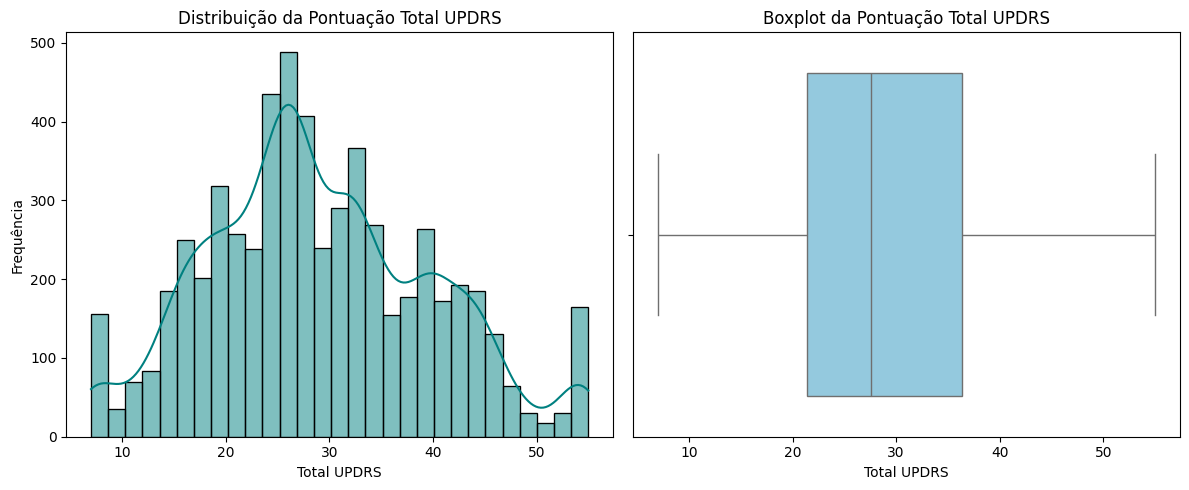


Estatísticas da variável alvo (Total UPDRS):
Média: 29.02
Mediana: 27.58
Desvio Padrão: 10.70
Mínimo: 7.00
Máximo: 54.99


In [4]:
plt.figure(figsize=(12, 5))

# Histograma com curva KDE
plt.subplot(1, 2, 1)
sns.histplot(parkinsons_df['total_UPDRS'], kde=True, color='teal')
plt.title('Distribuição da Pontuação Total UPDRS')
plt.xlabel('Total UPDRS')
plt.ylabel('Frequência')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=parkinsons_df['total_UPDRS'], color='skyblue')
plt.title('Boxplot da Pontuação Total UPDRS')
plt.xlabel('Total UPDRS')

plt.tight_layout()
plt.show()

# Estatísticas da variável alvo
print("\nEstatísticas da variável alvo (Total UPDRS):")
print(f"Média: {parkinsons_df['total_UPDRS'].mean():.2f}")
print(f"Mediana: {parkinsons_df['total_UPDRS'].median():.2f}")
print(f"Desvio Padrão: {parkinsons_df['total_UPDRS'].std():.2f}")
print(f"Mínimo: {parkinsons_df['total_UPDRS'].min():.2f}")
print(f"Máximo: {parkinsons_df['total_UPDRS'].max():.2f}")

## 4: Matriz de Correlação

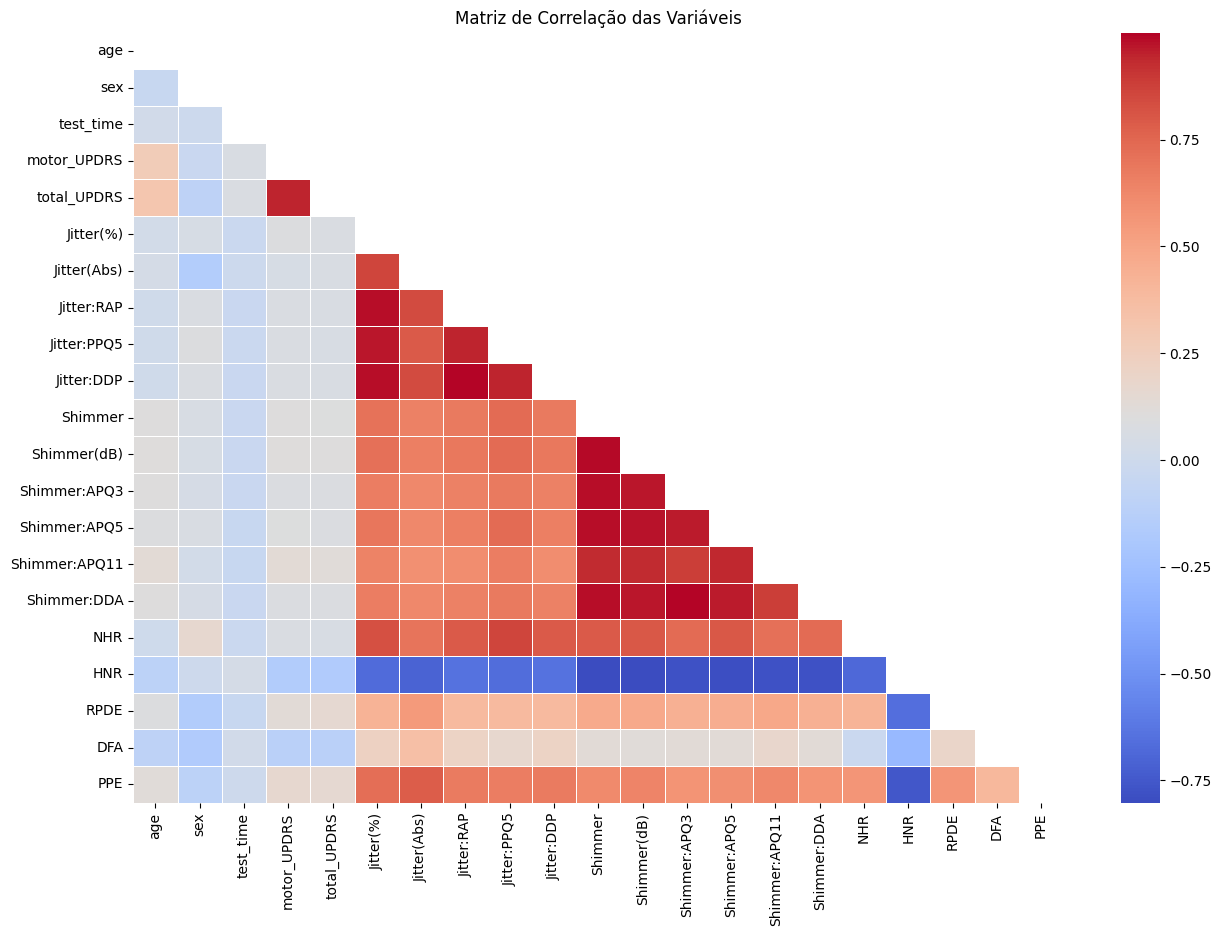


Correlações com Total UPDRS (mais fortes):
total_UPDRS      1.000000
motor_UPDRS      0.947231
age              0.310290
RPDE             0.156897
PPE              0.156195
Shimmer:APQ11    0.120838
Shimmer(dB)      0.098790
Shimmer          0.092141
Shimmer:APQ5     0.083467
Shimmer:DDA      0.079363
Name: total_UPDRS, dtype: float64


In [5]:
plt.figure(figsize=(15, 10))
corr = parkinsons_df.drop(columns=['subject#']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis')
plt.show()

# Exibir as correlações mais fortes com a variável alvo
correlations = parkinsons_df.drop(columns=['subject#']).corr()['total_UPDRS'].sort_values(ascending=False)
print("\nCorrelações com Total UPDRS (mais fortes):")
print(correlations.head(10))

## 6: Relação entre Idade, Sexo e UPDRS

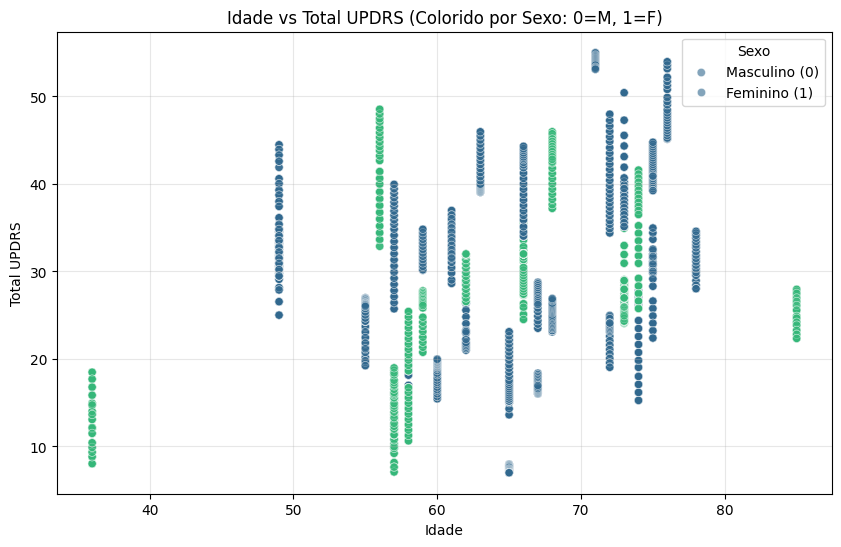

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=parkinsons_df, x='age', y='total_UPDRS', hue='sex', palette='viridis', alpha=0.6)
plt.title('Idade vs Total UPDRS (Colorido por Sexo: 0=M, 1=F)')
plt.xlabel('Idade')
plt.ylabel('Total UPDRS')
plt.legend(title='Sexo', labels=['Masculino (0)', 'Feminino (1)'])
plt.grid(True, alpha=0.3)
plt.show()

## Pré-processamento e Engenharia de Features

In [11]:
# Definindo a variável alvo
TARGET = 'total_UPDRS'

# Tratando 'sex' como categórica
parkinsons_df['sex'] = parkinsons_df['sex'].astype('object')

# Separando features (X) e target (y)
X = parkinsons_df.drop(columns=['subject#', 'motor_UPDRS', TARGET])
y = parkinsons_df[TARGET]

# Identificando colunas
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Engenharia de Features
X['test_time_squared'] = X['test_time'] ** 2
numerical_cols.append('test_time_squared')

print(f"Features numéricas: {len(numerical_cols)}")
print(f"Features categóricas: {len(categorical_cols)}")
print(f"Total de features: {len(numerical_cols) + len(categorical_cols)}")

# Pipelines de pré-processamento
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Dividindo os dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nDados de treino: {X_train.shape}")
print(f"Dados de teste: {X_test.shape}")

Features numéricas: 19
Features categóricas: 1
Total de features: 20

Dados de treino: (4700, 20)
Dados de teste: (1175, 20)


## 11: Algoritmo Genético - Definição das Classes

In [13]:
class IndividuoGA:
    def __init__(self, num_features_num, num_features_cat):
        self.features_selecionadas_num = [random.randint(0, 1) for _ in range(num_features_num)]
        self.features_selecionadas_cat = [random.randint(0, 1) for _ in range(num_features_cat)]
        self.tipo_modelo = random.randint(0, 2)
        self.parametros = {
            'max_depth': random.randint(3, 20),
            'min_samples_split': random.randint(2, 20),
            'min_samples_leaf': random.randint(1, 10),
            'random_state': 42
        }
        self.fitness = None

    def copiar(self):
        novo = IndividuoGA(len(self.features_selecionadas_num), len(self.features_selecionadas_cat))
        novo.features_selecionadas_num = self.features_selecionadas_num.copy()
        novo.features_selecionadas_cat = self.features_selecionadas_cat.copy()
        novo.tipo_modelo = self.tipo_modelo
        novo.parametros = self.parametros.copy()
        novo.fitness = self.fitness
        return novo

class AlgoritmoGenetico:
    def __init__(self, tamanho_populacao=20, num_geracoes=10, taxa_mutacao=0.2, pct_elite=0.2):
        self.tamanho_populacao = tamanho_populacao
        self.num_geracoes = num_geracoes
        self.taxa_mutacao = taxa_mutacao
        self.pct_elite = pct_elite
        self.historico_fitness = []
        self.melhor_individuo = None

    def criar_populacao_inicial(self, num_features_num, num_features_cat):
        return [IndividuoGA(num_features_num, num_features_cat) for _ in range(self.tamanho_populacao)]

    def avaliar_fitness(self, individuo, X, y, numerical_cols, categorical_cols):
        features_num_ativas = [numerical_cols[i] for i in range(len(numerical_cols))
                              if individuo.features_selecionadas_num[i] == 1]
        features_cat_ativas = [categorical_cols[i] for i in range(len(categorical_cols))
                              if individuo.features_selecionadas_cat[i] == 1]

        if not features_num_ativas and not features_cat_ativas:
            individuo.fitness = float('inf')
            return

        transformers = []
        if features_num_ativas:
            transformers.append(('num', numerical_transformer, features_num_ativas))
        if features_cat_ativas:
            transformers.append(('cat', categorical_transformer, features_cat_ativas))

        preprocessor_custom = ColumnTransformer(transformers, remainder='drop')

        if individuo.tipo_modelo == 0:
            modelo = DecisionTreeRegressor(**individuo.parametros)
        elif individuo.tipo_modelo == 1:
            modelo = RandomForestRegressor(**individuo.parametros)
        else:
            modelo = GradientBoostingRegressor(**individuo.parametros)

        pipeline = Pipeline([('preprocessor', preprocessor_custom), ('regressor', modelo)])

        try:
            scores = cross_val_score(pipeline, X, y, cv=3, scoring='neg_root_mean_squared_error')
            individuo.fitness = -np.mean(scores)
        except:
            individuo.fitness = float('inf')

    def evoluir(self, X, y, numerical_cols, categorical_cols):
        num_features_num = len(numerical_cols)
        num_features_cat = len(categorical_cols)
        populacao = self.criar_populacao_inicial(num_features_num, num_features_cat)

        for geracao in range(self.num_geracoes):
            for individuo in populacao:
                if individuo.fitness is None:
                    self.avaliar_fitness(individuo, X, y, numerical_cols, categorical_cols)

            populacao.sort(key=lambda x: x.fitness if x.fitness is not None else float('inf'))

            if self.melhor_individuo is None or populacao[0].fitness < self.melhor_individuo.fitness:
                self.melhor_individuo = populacao[0].copiar()

            self.historico_fitness.append(self.melhor_individuo.fitness)
            print(f"Geração {geracao+1}/{self.num_geracoes} - Melhor RMSE: {self.melhor_individuo.fitness:.4f}")

            num_elite = int(self.tamanho_populacao * self.pct_elite)
            nova_populacao = populacao[:num_elite]

            while len(nova_populacao) < self.tamanho_populacao:
                pai1, pai2 = random.sample(populacao[:self.tamanho_populacao // 2], 2)
                filho = pai1.copiar()

                ponto = random.randint(0, num_features_num)
                filho.features_selecionadas_num = pai1.features_selecionadas_num[:ponto] + pai2.features_selecionadas_num[ponto:]

                if random.random() < self.taxa_mutacao:
                    idx = random.randint(0, num_features_num - 1)
                    filho.features_selecionadas_num[idx] = 1 - filho.features_selecionadas_num[idx]

                filho.fitness = None
                nova_populacao.append(filho)

            populacao = nova_populacao

        return self.melhor_individuo

## 12: Execução do Algoritmo Genético

Geração 1/10 - Melhor RMSE: 2.1243
Geração 2/10 - Melhor RMSE: 2.1243
Geração 3/10 - Melhor RMSE: 2.1243
Geração 4/10 - Melhor RMSE: 2.1243
Geração 5/10 - Melhor RMSE: 2.1243
Geração 6/10 - Melhor RMSE: 2.0427
Geração 7/10 - Melhor RMSE: 2.0427
Geração 8/10 - Melhor RMSE: 2.0427
Geração 9/10 - Melhor RMSE: 2.0212
Geração 10/10 - Melhor RMSE: 1.9490


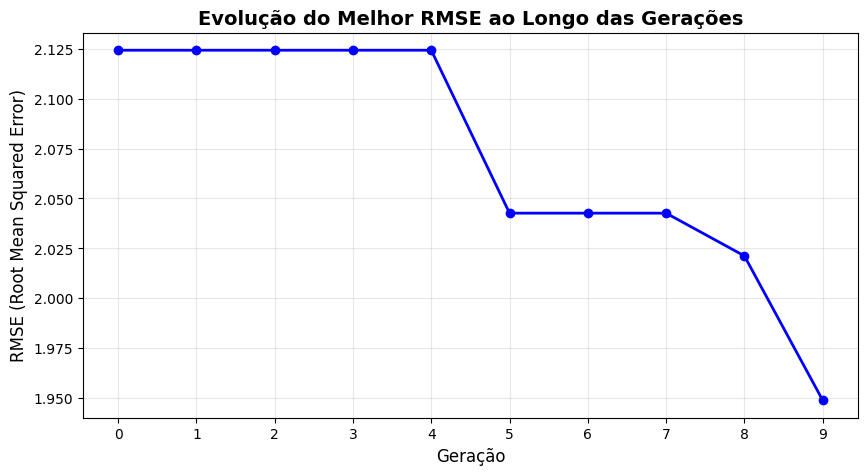

In [14]:
# Configurar e executar o AG
ga = AlgoritmoGenetico(tamanho_populacao=20, num_geracoes=10)
melhor_solucao = ga.evoluir(X_train, y_train, numerical_cols, categorical_cols)

# Gráfico de evolução
plt.figure(figsize=(10, 5))
plt.plot(ga.historico_fitness, marker='o', color='blue', linewidth=2)
plt.title('Evolução do Melhor RMSE ao Longo das Gerações', fontsize=14, fontweight='bold')
plt.xlabel('Geração', fontsize=12)
plt.ylabel('RMSE (Root Mean Squared Error)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(len(ga.historico_fitness)))
plt.show()

 ## 13: Avaliação do Modelo Final

In [15]:
# Identificar features selecionadas
sel_n = [numerical_cols[i] for i, v in enumerate(melhor_solucao.features_selecionadas_num) if v == 1]
sel_c = [categorical_cols[i] for i, v in enumerate(melhor_solucao.features_selecionadas_cat) if v == 1]

# Construir pipeline final
transformers = []
if sel_n:
    transformers.append(('num', numerical_transformer, sel_n))
if sel_c:
    transformers.append(('cat', categorical_transformer, sel_c))

preprocessor_final = ColumnTransformer(transformers, remainder='drop')

modelos = [DecisionTreeRegressor, RandomForestRegressor, GradientBoostingRegressor]
modelo_final = modelos[melhor_solucao.tipo_modelo](**melhor_solucao.parametros)

pipeline_final = Pipeline([
    ('preprocessor', preprocessor_final),
    ('regressor', modelo_final)
])

# Treinar e avaliar
pipeline_final.fit(X_train, y_train)
y_pred = pipeline_final.predict(X_test)

# Métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = np.mean(np.abs(y_test - y_pred))

print("AVALIAÇÃO DO MODELO FINAL")
print("="*40)
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")

AVALIAÇÃO DO MODELO FINAL
RMSE: 1.5544
R²: 0.9782
MAE: 0.6370


## 14: Gráfico de Dispersão - Real vs Previsto

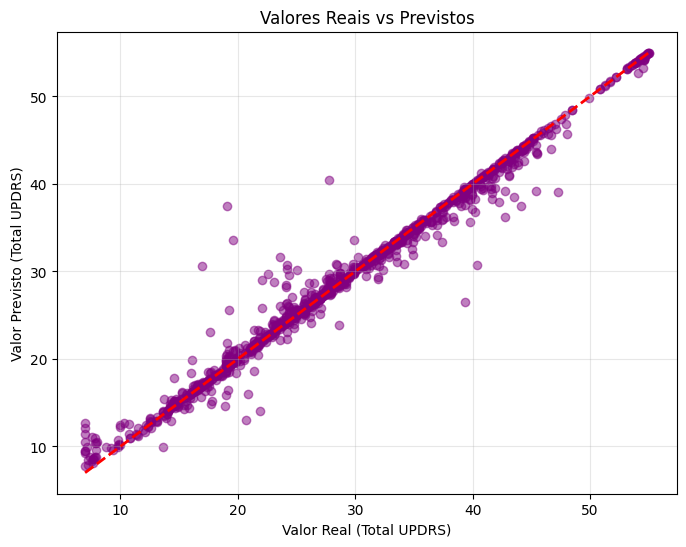

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real (Total UPDRS)')
plt.ylabel('Valor Previsto (Total UPDRS)')
plt.title('Valores Reais vs Previstos')
plt.grid(True, alpha=0.3)
plt.show()

## 15: Análise de Erros - Viés e Distribuição

ANÁLISE DE ERROS
Viés (Média dos Erros): -0.0187
RMSE: 1.5544
R²: 0.9782
MAE: 0.6370
Desvio Padrão dos Erros: 1.5543

Interpretação: O viés está próximo de zero, indicando que o modelo não está
superestimando ou subestimando sistematicamente os valores previstos.


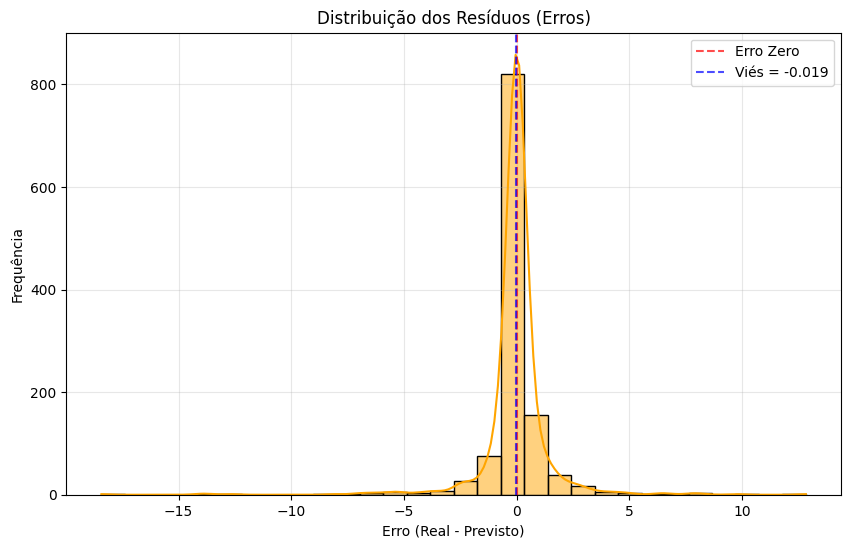


ESTATÍSTICAS DOS ERROS:
Mínimo: -18.4220
25º Percentil: -0.1689
Mediana: 0.0028
75º Percentil: 0.1837
Máximo: 12.8375

986 de 1175 previsões (83.9%) têm erro absoluto menor que 1 ponto.
1084 de 1175 previsões (92.3%) têm erro absoluto menor que 2 pontos.


In [17]:
# Calcular erros
errors = y_test - y_pred

# 1. Viés (média dos erros)
bias = np.mean(errors)

print("ANÁLISE DE ERROS")
print("="*40)
print(f"Viés (Média dos Erros): {bias:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Desvio Padrão dos Erros: {np.std(errors):.4f}")

# Interpretação do viés
if abs(bias) < 0.1:
    print("\nInterpretação: O viés está próximo de zero, indicando que o modelo não está")
    print("superestimando ou subestimando sistematicamente os valores previstos.")
elif bias > 0:
    print(f"\nInterpretação: O viés positivo ({bias:.4f}) indica que o modelo tende a")
    print("subestimar ligeiramente os valores reais (prevê menos do que o real).")
else:
    print(f"\nInterpretação: O viés negativo ({bias:.4f}) indica que o modelo tende a")
    print("superestimar ligeiramente os valores reais (prevê mais do que o real).")

# 2. Distribuição dos erros
plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True, color='orange', bins=30)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Erro Zero')
plt.axvline(x=bias, color='blue', linestyle='--', alpha=0.7, label=f'Viés = {bias:.3f}')
plt.xlabel('Erro (Real - Previsto)')
plt.ylabel('Frequência')
plt.title('Distribuição dos Resíduos (Erros)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Estatísticas dos erros
print("\nESTATÍSTICAS DOS ERROS:")
print(f"Mínimo: {np.min(errors):.4f}")
print(f"25º Percentil: {np.percentile(errors, 25):.4f}")
print(f"Mediana: {np.median(errors):.4f}")
print(f"75º Percentil: {np.percentile(errors, 75):.4f}")
print(f"Máximo: {np.max(errors):.4f}")

# 4. Percentual de acertos
print(f"\n{np.sum(np.abs(errors) < 1):.0f} de {len(errors)} previsões ({100*np.sum(np.abs(errors) < 1)/len(errors):.1f}%) têm erro absoluto menor que 1 ponto.")
print(f"{np.sum(np.abs(errors) < 2):.0f} de {len(errors)} previsões ({100*np.sum(np.abs(errors) < 2)/len(errors):.1f}%) têm erro absoluto menor que 2 pontos.")

 ## 16: Erro por Faixa de Valor

/tmp/ipykernel_5262/1320450031.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=error_by_range, x='Faixa_UPDRS', y='Erro', palette='viridis')


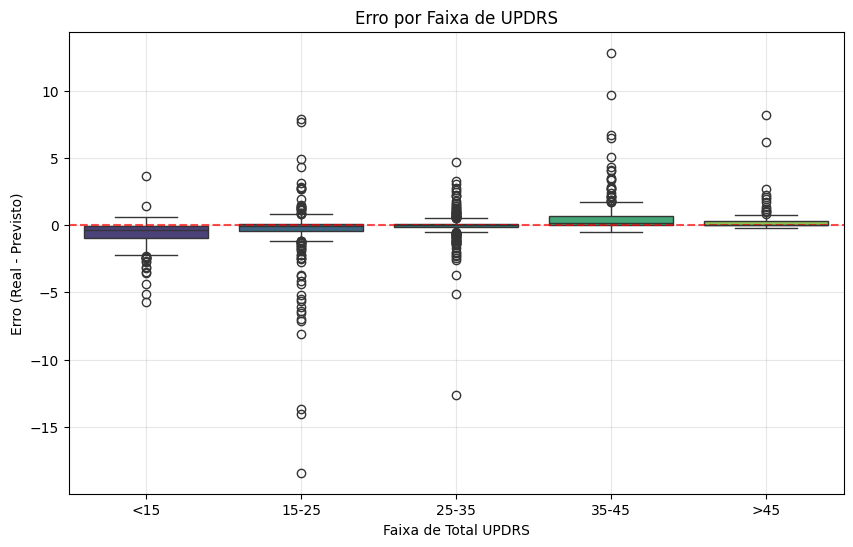

Estatísticas do Erro por Faixa de UPDRS:
             count      mean       std        min       25%       50%  \
Faixa_UPDRS                                                             
<15          102.0 -0.727906  1.306717  -5.714271 -0.932970 -0.321186   
15-25        345.0 -0.388001  2.048512 -18.421992 -0.433322 -0.046841   
25-35        417.0 -0.021655  0.959922 -12.639600 -0.140146  0.001838   
35-45        238.0  0.674186  1.433634  -0.541145  0.027588  0.178877   
>45           73.0  0.476082  1.300345  -0.181489 -0.016532  0.025019   

                  75%        max  
Faixa_UPDRS                       
<15         -0.028798   3.697631  
15-25        0.062656   7.891563  
25-35        0.122190   4.697640  
35-45        0.713311  12.837484  
>45          0.288430   8.221748  


/tmp/ipykernel_5262/1320450031.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(error_by_range.groupby('Faixa_UPDRS')['Erro'].describe())


In [18]:
# Análise de erro por faixas de UPDRS
plt.figure(figsize=(10, 6))

# Criar faixas
bins = [0, 15, 25, 35, 45, 60]
labels = ['<15', '15-25', '25-35', '35-45', '>45']
y_test_binned = pd.cut(y_test, bins=bins, labels=labels, right=False)

error_by_range = pd.DataFrame({'Erro': errors, 'Faixa_UPDRS': y_test_binned})
sns.boxplot(data=error_by_range, x='Faixa_UPDRS', y='Erro', palette='viridis')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.title('Erro por Faixa de UPDRS')
plt.xlabel('Faixa de Total UPDRS')
plt.ylabel('Erro (Real - Previsto)')
plt.grid(True, alpha=0.3)
plt.show()

# Estatísticas por faixa
print("Estatísticas do Erro por Faixa de UPDRS:")
print(error_by_range.groupby('Faixa_UPDRS')['Erro'].describe())

 ## 17: Detalhamento do Modelo Final

In [19]:
print("MODELO FINAL SELECIONADO")
print("="*40)

modelos_nomes = {
    0: "Decision Tree Regressor (Árvore de Decisão)",
    1: "Random Forest Regressor (Floresta Aleatória)",
    2: "Gradient Boosting Regressor (Gradient Boosting)"
}

print(f"Modelo: {modelos_nomes[melhor_solucao.tipo_modelo]}")
print("\nHiperparâmetros Otimizados:")
for key, value in melhor_solucao.parametros.items():
    if key != 'random_state':
        print(f"  • {key}: {value}")

print(f"\nFeatures Selecionadas ({len(sel_n) + len(sel_c)}):")
if sel_n:
    print("  Numéricas:")
    for i, feat in enumerate(sel_n, 1):
        print(f"    {i}. {feat}")
if sel_c:
    print("  Categóricas:")
    for i, feat in enumerate(sel_c, 1):
        print(f"    {i}. {feat}")

MODELO FINAL SELECIONADO
Modelo: Random Forest Regressor (Floresta Aleatória)

Hiperparâmetros Otimizados:
  • max_depth: 16
  • min_samples_split: 6
  • min_samples_leaf: 1

Features Selecionadas (11):
  Numéricas:
    1. age
    2. test_time
    3. Jitter(%)
    4. Jitter(Abs)
    5. Jitter:PPQ5
    6. Shimmer
    7. Shimmer:APQ3
    8. RPDE
    9. DFA
    10. PPE
  Categóricas:
    1. sex


## 18: Redução de Dimensionalidade

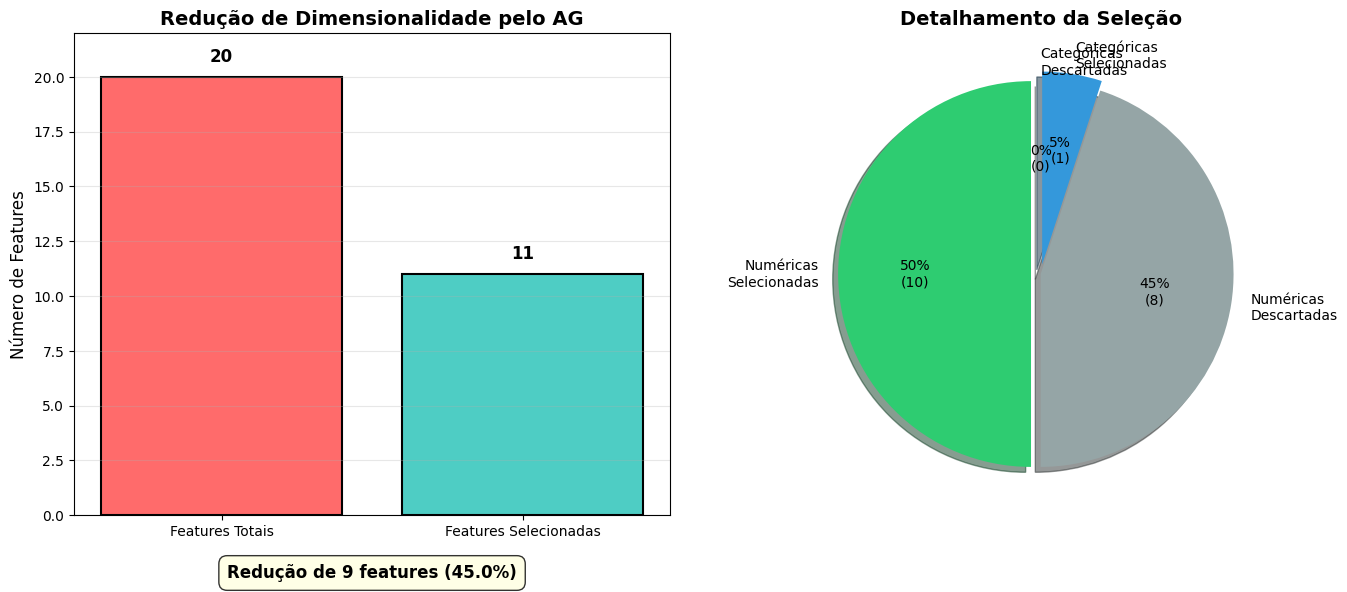

Redução de 9 features (45.0% de redução)


In [20]:
# Dados da redução
total_features = len(numerical_cols) + len(categorical_cols)
selected_total = len(sel_n) + len(sel_c)
reduction = total_features - selected_total
reduction_pct = (reduction / total_features) * 100

# Gráfico de barras
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Barras comparativas
categories = ['Features Totais', 'Features Selecionadas']
values = [total_features, selected_total]
colors = ['#FF6B6B', '#4ECDC4']

bars = ax1.bar(categories, values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Redução de Dimensionalidade pelo AG', fontsize=14, fontweight='bold')
ax1.set_ylabel('Número de Features', fontsize=12)
ax1.set_ylim(0, total_features * 1.1)

for bar, value in zip(bars, values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{value}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax1.text(0.5, -0.12, f'Redução de {reduction} features ({reduction_pct:.1f}%)',
         ha='center', va='center', transform=ax1.transAxes, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))
ax1.grid(True, axis='y', alpha=0.3)

# Gráfico de pizza - detalhamento
labels = ['Numéricas\nSelecionadas', 'Numéricas\nDescartadas',
          'Categóricas\nSelecionadas', 'Categóricas\nDescartadas']
sizes = [
    len(sel_n),
    len(numerical_cols) - len(sel_n),
    len(sel_c),
    len(categorical_cols) - len(sel_c)
]
colors_pie = ['#2ECC71', '#95A5A6', '#3498DB', '#95A5A6']
explode = (0.05, 0, 0.05, 0)

ax2.pie(sizes, labels=labels, colors=colors_pie, explode=explode,
        autopct=lambda pct: f'{pct:.0f}%\n({int(pct*sum(sizes)/100)})',
        shadow=True, startangle=90, textprops={'fontsize': 10})
ax2.set_title('Detalhamento da Seleção', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Redução de {reduction} features ({reduction_pct:.1f}% de redução)")

## 19: Importância das Features

/tmp/ipykernel_5262/3417603626.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature', palette='magma')


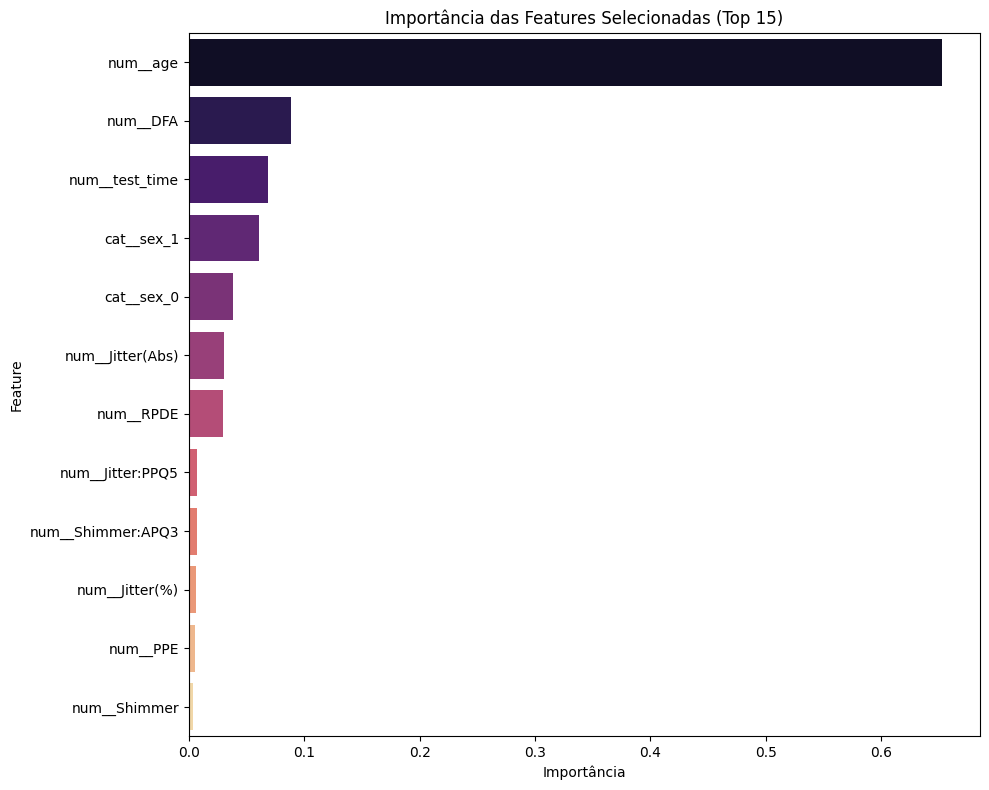


Top 5 Features Mais Importantes:
           feature  importance
0         num__age    0.652827
8         num__DFA    0.088265
1   num__test_time    0.068619
11      cat__sex_1    0.060984
10      cat__sex_0    0.038312


In [21]:
if hasattr(pipeline_final.named_steps['regressor'], 'feature_importances_'):
    importances = pipeline_final.named_steps['regressor'].feature_importances_
    feature_names = pipeline_final.named_steps['preprocessor'].get_feature_names_out()

    # Criar DataFrame e ordenar
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature', palette='magma')
    plt.title('Importância das Features Selecionadas (Top 15)')
    plt.xlabel('Importância')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    print("\nTop 5 Features Mais Importantes:")
    print(feature_importance_df.head(5))

## 20: Resumo Final

In [22]:
print("="*60)
print("RESUMO FINAL DO PROJETO")
print("="*60)

print("\n1. PROBLEMA:")
print("   Prever a pontuação Total UPDRS (gravidade do Parkinson)")
print("   utilizando características vocais e demográficas dos pacientes.")

print("\n2. ABORDAGEM:")
print(f"   • {total_features} features iniciais.")
print(f"   • Redução para {selected_total} features ({reduction_pct:.1f}% de redução).")
print(f"   • Algoritmo Genético com {ga.num_geracoes} gerações e {ga.tamanho_populacao} indivíduos.")
print(f"   • Modelo final: {modelos_nomes[melhor_solucao.tipo_modelo]}")

print("\n3. RESULTADOS:")
print(f"   • RMSE: {rmse:.4f}")
print(f"   • R²: {r2:.4f}")
print(f"   • MAE: {mae:.4f}")
print(f"   • Viés: {bias:.4f}")

print("\n4. INTERPRETAÇÃO CLÍNICA:")
print("   • O modelo utiliza medidas vocais (Jitter, Shimmer, NHR, HNR)")
print("   • Estas medidas são biomarcadores não-invasivos importantes.")
print("   • O modelo pode auxiliar no monitoramento remoto da doença.")

print("\n5. TRABALHOS FUTUROS:")
print("   • Testar outros modelos (XGBoost, SVR).")
print("   • Explorar novas features (interações entre variáveis).")
print("   • Analisar performance por subgrupos (sexo, idade).")
print("   • Utilizar SHAP para interpretabilidade do modelo.")

RESUMO FINAL DO PROJETO

1. PROBLEMA:
   Prever a pontuação Total UPDRS (gravidade do Parkinson)
   utilizando características vocais e demográficas dos pacientes.

2. ABORDAGEM:
   • 20 features iniciais.
   • Redução para 11 features (45.0% de redução).
   • Algoritmo Genético com 10 gerações e 20 indivíduos.
   • Modelo final: Random Forest Regressor (Floresta Aleatória)

3. RESULTADOS:
   • RMSE: 1.5544
   • R²: 0.9782
   • MAE: 0.6370
   • Viés: -0.0187

4. INTERPRETAÇÃO CLÍNICA:
   • O modelo utiliza medidas vocais (Jitter, Shimmer, NHR, HNR)
   • Estas medidas são biomarcadores não-invasivos importantes.
   • O modelo pode auxiliar no monitoramento remoto da doença.

5. TRABALHOS FUTUROS:
   • Testar outros modelos (XGBoost, SVR).
   • Explorar novas features (interações entre variáveis).
   • Analisar performance por subgrupos (sexo, idade).
   • Utilizar SHAP para interpretabilidade do modelo.
